In [ ]:
import os
import sys

import pandas as pd
from competitors import (
    export_benchmark_matrices,
    get_rezaeian_features,
    map_competitor_features,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from utils import load_metabric_data

In [ ]:
# Load Data
df = load_metabric_data()
df_LumA = df[df['pam50_+_claudin-low_subtype'] == 'LumA'].copy()
df_LumA['target_mortality'] = df_LumA['death_from_cancer'].apply(
    lambda x: 1 if str(x).strip().lower() == 'died of disease' else 0)

Fetching METABRIC dataset from Kaggle...


In [ ]:
# Isolate features
rezaeian_list = get_rezaeian_features()
features = map_competitor_features(df_LumA.columns, rezaeian_list)

Mapped 53 features out of the 39 features selected by the competitor.


In [ ]:
X = df_LumA[features]
y = df_LumA['target_mortality']

In [ ]:
# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Ensure all feature columns are numeric
for col in X_train.columns:
    # Convert column to numeric, coercing errors (non-numeric strings) to NaN
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

    # Fill NaN values created by coercion with the mean of the training column
    if X_train[col].isnull().any():
        mean_val = X_train[col].mean()
        X_train[col] = X_train[col].fillna(mean_val)
        X_test[col] = X_test[col].fillna(mean_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled.shape, y_train.shape)

(543, 53) (543,)


In [ ]:
# Train using SVM
competitor_model = SVC(probability=True, C=1, kernel='rbf', class_weight='balanced', random_state=42)
competitor_model.fit(X_train_scaled, y_train)
print("Competitor model (SVM) trained on Rezaeian et al. features.")

Competitor model (SVM) trained on Rezaeian et al. features.


WITHOUT THRESHOLD TUNING (Default 0.5)
[threshold = 0.5] Average Precision (AP): 0.295
[threshold = 0.5] PR-Optimal Threshold (Max F1): 0.206


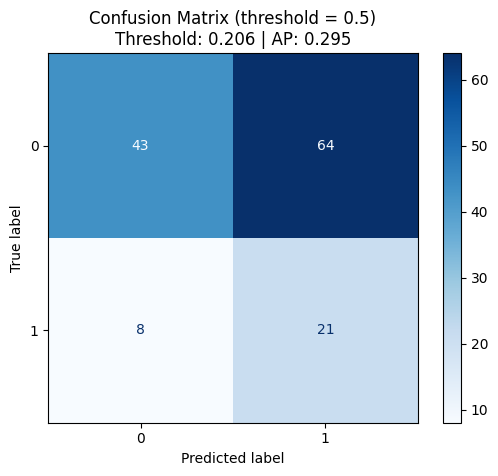

In [ ]:
print("WITHOUT THRESHOLD TUNING (Default 0.5)")
# We use the function but pass a specific threshold to demonstrate the 'raw' result
# The function implicitly uses a default threshold of 0.5 if not specified.
export_benchmark_matrices(
    competitor_model,
    X_test_scaled,
    y_test,
    suffix="threshold = 0.5",
    save_file=False
);

WITH THRESHOLD TUNING (Precision-Recall Optimal)
[Tuned threshold based on PR Curve] Average Precision (AP): 0.295
[Tuned threshold based on PR Curve] PR-Optimal Threshold (Max F1): 0.206


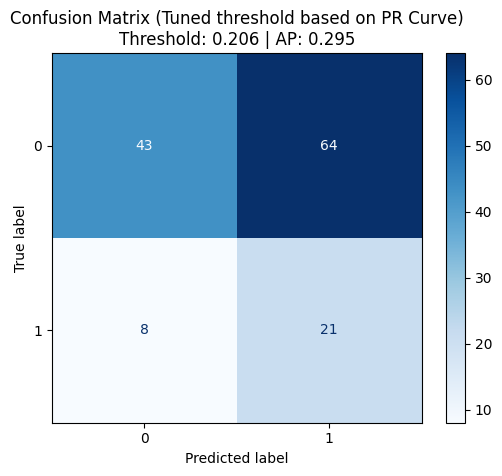

(np.float64(0.2060223892816789), 0.294991852279259)

In [ ]:
print("WITH THRESHOLD TUNING (Precision-Recall Optimal)")
# The function automatically calculates the best PR threshold if we don't force one
export_benchmark_matrices(
    competitor_model,
    X_test_scaled,
    y_test,
    suffix="Tuned threshold based on PR Curve",
    save_file=False
);